In [1]:
from pathlib import Path
import sys
sys.path.insert(0, str(Path().resolve().parent / "src"))

In [ ]:
import pandas as pd
import matplotlib as plt
from config import PROCESSED_DIR
import seaborn as sns
import numpy as np

In [3]:
historical = pd.read_parquet(PROCESSED_DIR / "historical_price_demand.parquet")

In [4]:
print(f"Historical has {historical.shape[0]} rows")
print(f"Historical has {historical.shape[1]} columns")

Historical has 1052640 rows
Historical has 5 columns


In [5]:
cols =  historical.dtypes
print(f"The column names and data types are \n\n{cols}")

The column names and data types are 

REGION                       str
SETTLEMENTDATE    datetime64[us]
TOTALDEMAND              float64
RRP                      float64
PERIODTYPE                   str
dtype: object


In [6]:
historical.info()
print("\nThere are no non-null values")

<class 'pandas.DataFrame'>
RangeIndex: 1052640 entries, 0 to 1052639
Data columns (total 5 columns):
 #   Column          Non-Null Count    Dtype         
---  ------          --------------    -----         
 0   REGION          1052640 non-null  str           
 1   SETTLEMENTDATE  1052640 non-null  datetime64[us]
 2   TOTALDEMAND     1052640 non-null  float64       
 3   RRP             1052640 non-null  float64       
 4   PERIODTYPE      1052640 non-null  str           
dtypes: datetime64[us](1), float64(2), str(2)
memory usage: 49.0 MB

There are no non-null values


In [7]:
print(historical.head())

  REGION      SETTLEMENTDATE  TOTALDEMAND    RRP PERIODTYPE
0   NSW1 2024-01-01 00:05:00      6574.92  57.98      TRADE
1   NSW1 2024-01-01 00:10:00      6651.09  70.27      TRADE
2   NSW1 2024-01-01 00:15:00      6538.96  57.98      TRADE
3   NSW1 2024-01-01 00:20:00      6497.99  54.95      TRADE
4   NSW1 2024-01-01 00:25:00      6404.55  54.95      TRADE


In [8]:
print(historical["REGION"].value_counts())
print("\nThere are 5 regions, and each has the same number of datapoints")

print(f"\nThe timespan ranges from {min(historical["SETTLEMENTDATE"])} to {max(historical["SETTLEMENTDATE"])}")

REGION
NSW1    210528
QLD1    210528
SA1     210528
TAS1    210528
VIC1    210528
Name: count, dtype: int64

There are 5 regions, and each has the same number of datapoints

The timespan ranges from 2024-01-01 00:05:00 to 2026-01-01 00:00:00


In [9]:
averages = historical[["TOTALDEMAND", "RRP", "REGION"]].groupby("REGION").mean()
sds = historical[["TOTALDEMAND", "RRP", "REGION"]].groupby("REGION").std()
print(averages)
print("\nNSW has the highest average demand and price. \nVIC has the lowest average price. \nTAS has the lowest average demand")
print("\n")
print(sds)
print("\nNSW has the highest standard deviation for both demand and price.") 

        TOTALDEMAND         RRP
REGION                         
NSW1    7496.731805  117.190244
QLD1    6225.902912   98.204409
SA1     1301.366430   93.431519
TAS1    1094.428041   95.891113
VIC1    4806.983560   80.009624

NSW has the highest average demand and price. 
VIC has the lowest average price. 
TAS has the lowest average demand


        TOTALDEMAND         RRP
REGION                         
NSW1    1517.134302  591.971752
QLD1    1151.949349  403.638273
SA1      467.705206  490.848548
TAS1     156.035848  275.128465
VIC1    1161.371531  364.798108

NSW has the highest standard deviation for both demand and price.


<Axes: xlabel='REGION', ylabel='TOTALDEMAND'>

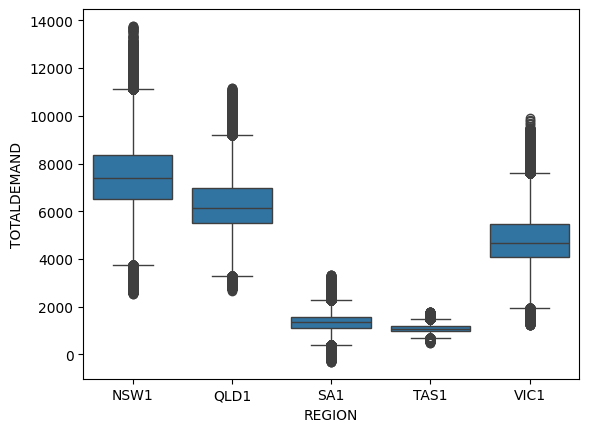

In [10]:
sns.boxplot(data = historical, x="REGION", y="TOTALDEMAND")

<Axes: xlabel='REGION', ylabel='RRP'>

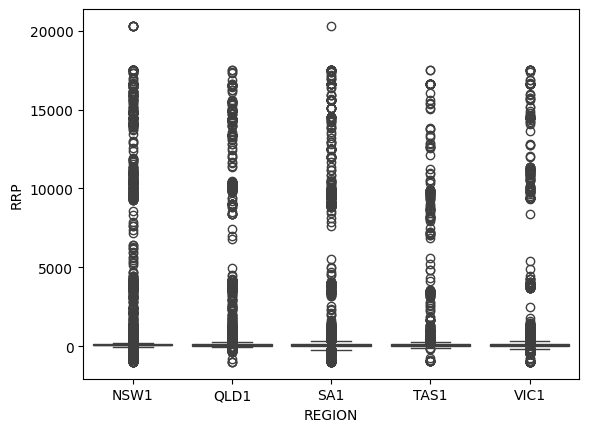

In [11]:
sns.boxplot(data = historical, x="REGION", y="RRP")

In [12]:
print("The RRP boxplot shows that there are a very large number of price spikes in the data. The plot itslef actually isn't that useful")

The RRP boxplot shows that there are a very large number of price spikes in the data. The plot itslef actually isn't that useful


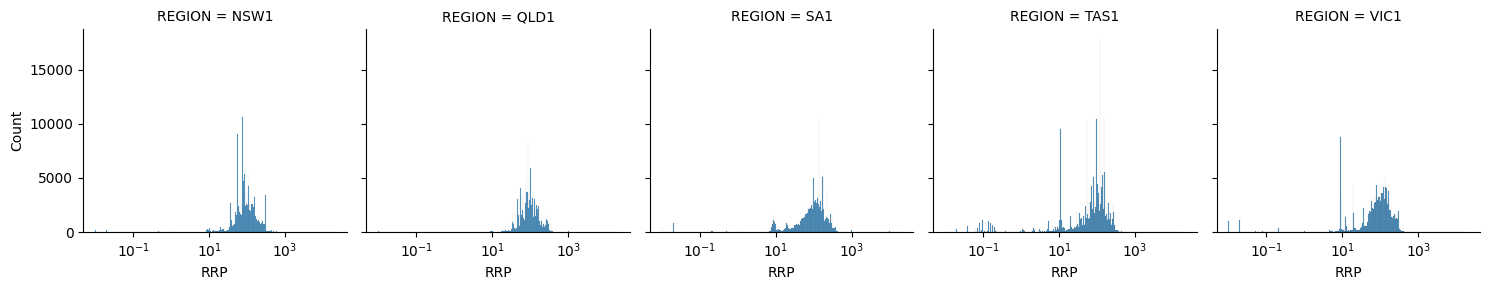

In [13]:
# sns.histplot(data=historical[historical["REGION"]=="NSW1"], x="RRP", bins=300, log_scale=True)

g = sns.FacetGrid(historical, col="REGION")
g.map(sns.histplot, "RRP", log_scale=True)

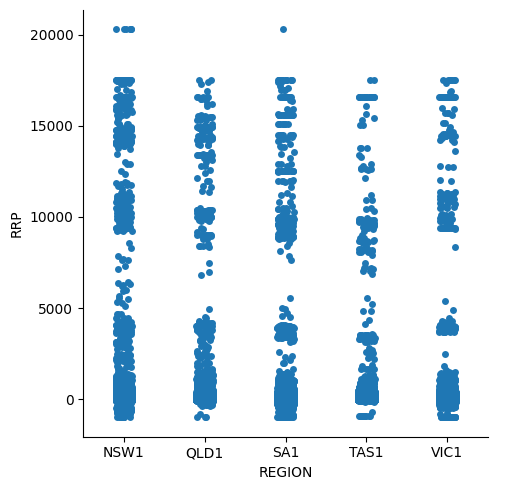

In [14]:
sns.catplot(data=historical, x="REGION", y="RRP", jitter=True)

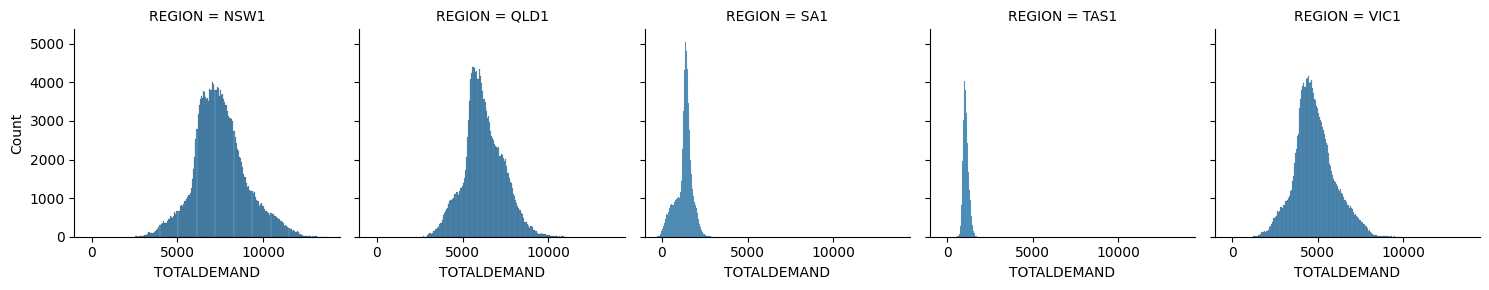

In [15]:
g = sns.FacetGrid(historical, col="REGION")
g.map(sns.histplot, "TOTALDEMAND")

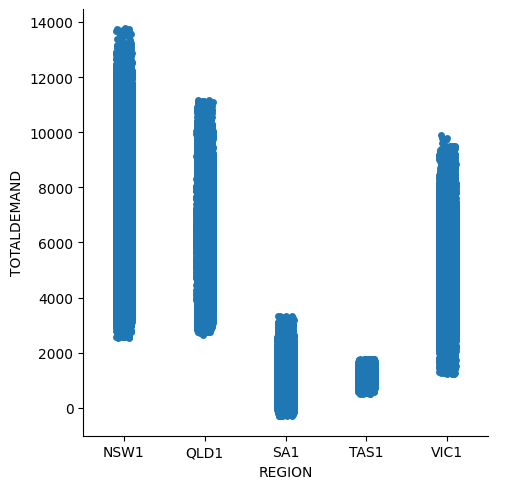

In [16]:
sns.catplot(data=historical, x="REGION", y="TOTALDEMAND", jitter=True)

timeespan
datapoints per group


<Axes: xlabel='HOUR', ylabel='TOTALDEMAND'>

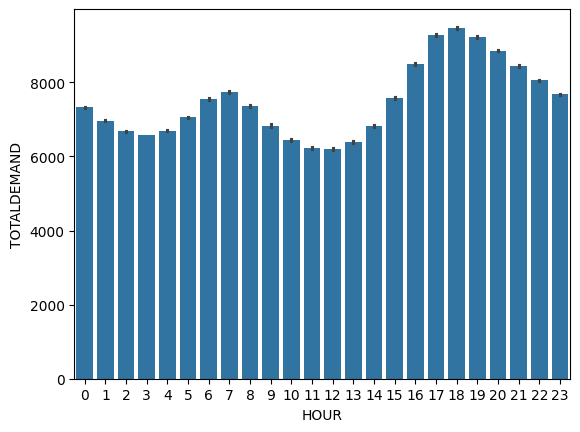

In [18]:
nsw = historical[historical["REGION"]=="NSW1"]
# nsw_time = nsw[["SETTLEMENTDATE", "TOTALDEMAND"]].groupby("SETTLEMENTDATE").mean()
# # averages = historical[["TOTALDEMAND", "RRP", "REGION"]].groupby("REGION").mean()

# sns.barplot(data=nsw_time, x="SETTLEMENTDATE", y="TOTALDEMAND")

nsw["HOUR"] = nsw["SETTLEMENTDATE"].dt.hour

sns.barplot(data=nsw, x="HOUR", y="TOTALDEMAND", estimator="mean")

/Users/keirenbrandt-sawdy/portfolio_projects/aemo_dashboard/.venv/lib/python3.13/site-packages/seaborn/axisgrid.py:718: UserWarning: Using the barplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


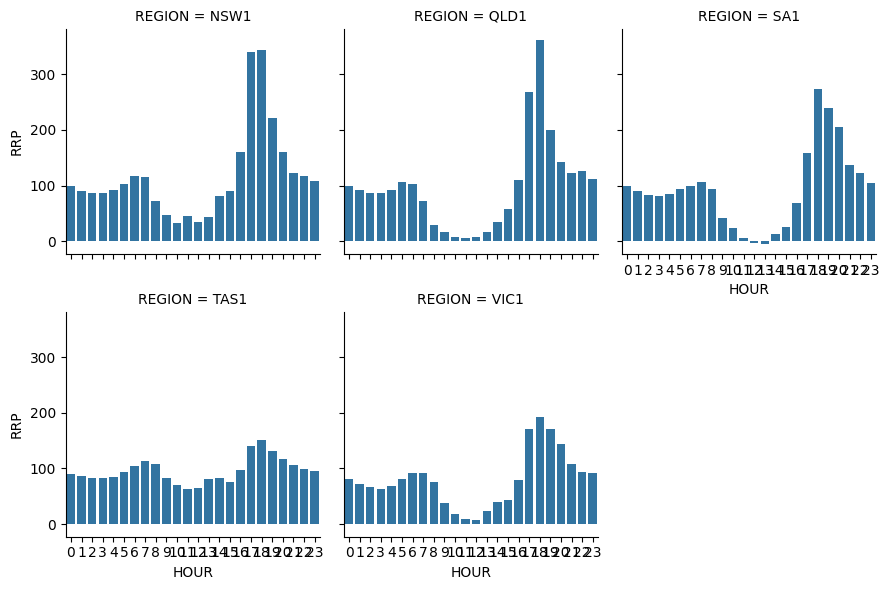

In [ ]:
# nsw = historical[historical["REGION"]=="NSW1"]
# nsw_time = nsw[["SETTLEMENTDATE", "TOTALDEMAND"]].groupby("SETTLEMENTDATE").mean()
# # averages = historical[["TOTALDEMAND", "RRP", "REGION"]].groupby("REGION").mean()

# sns.barplot(data=nsw_time, x="SETTLEMENTDATE", y="TOTALDEMAND")

historical["HOUR"] = historical["SETTLEMENTDATE"].dt.hour
hour_mean = (
    historical.groupby(["REGION", "HOUR"])["RRP"]
    .mean()
    .reset_index()
)

g = sns.FacetGrid(hour_mean, col="REGION", col_wrap=3)
g.map(sns.barplot, "HOUR", "RRP")
g.set_xticks(np.arrange(0,25,4))
